### Loading Train and Test Data

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import pandas as pd

X_train = pd.read_csv("X_train_prepared.csv", index_col=0)
y_train = pd.read_csv("y_train_prepared.csv", index_col=0).squeeze()

X_test  = pd.read_csv("X_test_processed.csv", index_col=0)
y_test  = pd.read_csv("y_test.csv", index_col=0).squeeze()

### Hyperparameter Tuning with GridSearchCV of KNeighbors Regressor

In [1]:
pipeline = Pipeline([
    ('selector', SelectKBest(f_regression)),
    ('knn', KNeighborsRegressor())
])

param_grid = {
    'selector__k':       [5, 8, 10, 12, 16],
    'knn__n_neighbors':  [3, 5, 10, 15, 20, 30],
    'knn__weights':      ['uniform', 'distance'],
    'knn__metric':       ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)

### Training and Evaluating the Best KNN Model

In [2]:
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV RMSE: {-grid_search.best_score_:.2f}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'distance', 'selector__k': 8}
Best CV RMSE: 75.31


In [3]:
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)

print(f"\n=== Tuned KNN ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred_best):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_best):.4f}")


=== Tuned KNN ===
MAE  : 69.83
RMSE : 87.25
R²   : 0.9087


### Plotting for Analysation

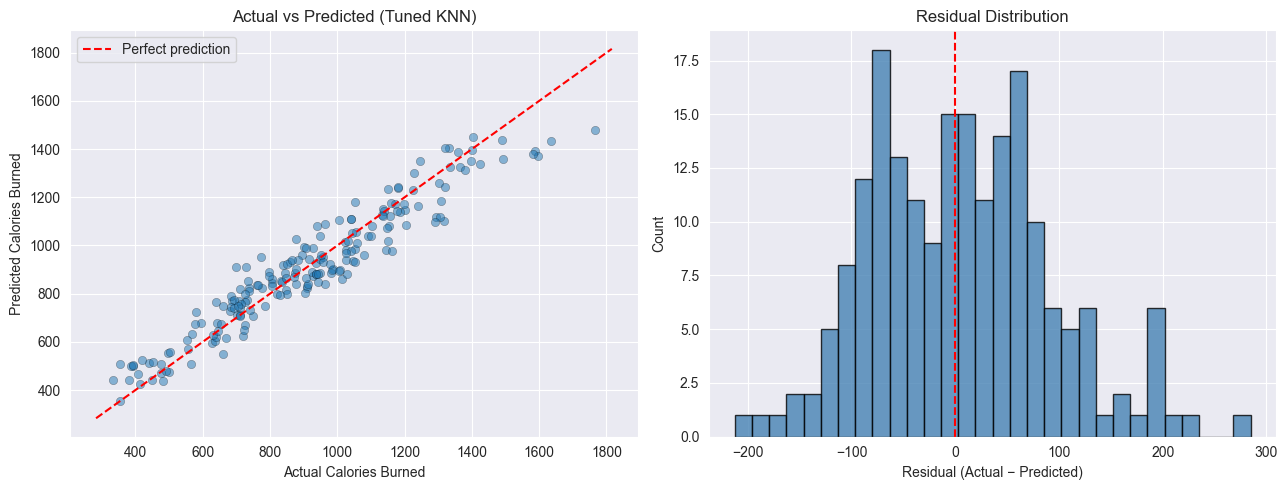

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.5, edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), y_pred_best.min()) - 50,
        max(y_test.max(), y_pred_best.max()) + 50]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Calories Burned")
ax.set_ylabel("Predicted Calories Burned")
ax.set_title("Actual vs Predicted (Tuned KNN)")
ax.legend()

residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=30, edgecolor="k", color="steelblue", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()